In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
class SalesAnalyzer:

    def __init__(self):
        self.data = None
        print("Analyzer Ready")

    def load_data(self, path):
        try:
            self.data = pd.read_csv(path)
            print("Dataset loaded successfully!")
        except:
            print("Error loading file!")

    def check_data(self):
        if self.data is None:
            print("Please load dataset first!")
            return False
        return True

    def explore(self):
        if not self.check_data():
            return

        print("\n== Explore Data ==")
        print("1. First 5 rows")
        print("2. Last 5 rows")
        print("3. Columns")
        print("4. Data types")
        print("5. Info")

        ch = int(input("Enter choice: "))

        match ch:
            case 1:
                print(self.data.head())
            case 2:
                print(self.data.tail())
            case 3:
                print(list(self.data.columns))
            case 4:
                print(self.data.dtypes)
            case 5:
                print(self.data.info())
            case _:
                print("Invalid choice")

    def operations(self):
        if not self.check_data():
            return

        print("\n== DataFrame Operations ==")
        print("1. Math operations")
        print("2. Combine (top + bottom)")
        print("3. Split data")

        ch = int(input("Enter choice: "))

        match ch:
            case 1:
                col = input("Enter numeric column: ")
                print("Sum:", self.data[col].sum())
                print("Mean:", self.data[col].mean())
                print("Max:", self.data[col].max())
                print("Min:", self.data[col].min())

            case 2:
                part1 = self.data.head(5)
                part2 = self.data.tail(5)
                print(pd.concat([part1, part2]))

            case 3:
                col = input("Enter column: ")
                val = input("Enter value: ")
                print(self.data[self.data[col] == val].head())

            case _:
                print("Invalid choice")

    def clean(self):
        if not self.check_data():
            return

        print("\n== Handle Missing Data ==")
        print("1. Show missing")
        print("2. Fill with mean")
        print("3. Drop rows")
        print("4. Replace with value")

        ch = int(input("Enter choice: "))

        match ch:
            case 1:
                miss = self.data.isnull().sum()
                total = miss.sum()
                print("Total missing:", total)
                if total == 0:
                    print("No missing values found!")
                else:
                    print(miss[miss > 0])

            case 2:
                self.data.fillna(self.data.mean(numeric_only=True), inplace=True)
                print("Filled with mean")

            case 3:
                self.data.dropna(inplace=True)
                print("Rows dropped")

            case 4:
                val = input("Enter value: ")
                self.data.fillna(val, inplace=True)
                print("Replaced missing")

            case _:
                print("Invalid choice")

    def stats(self):
        if not self.check_data():
            return

        print("\n== Statistics ==")
        print("1. Describe")
        print("2. Standard deviation")
        print("3. Variance")
        print("4. Aggregate")

        ch = int(input("Enter choice: "))

        match ch:
            case 1:
                print(self.data.describe())

            case 2:
                col = input("Enter column: ")
                print("Std:", self.data[col].std())

            case 3:
                col = input("Enter column: ")
                print("Variance:", self.data[col].var())

            case 4:
                col = input("Enter column: ")
                print("Sum:", self.data[col].sum())
                print("Min:", self.data[col].min())
                print("Max:", self.data[col].max())
                print("Mean:", self.data[col].mean())
                print("Count:", self.data[col].count())

            case _:
                print("Invalid choice")

    def visualize(self):
        if not self.check_data():
            return

        print("\n== Data Visualization ==")
        print("1. Bar")
        print("2. Line")
        print("3. Scatter")
        print("4. Pie")
        print("5. Histogram")
        print("6. Stack")

        ch = int(input("Enter choice: "))

        match ch:
            case 1:
                x = input("Enter category column: ")
                y = input("Enter numeric column: ")
                self.data.groupby(x)[y].sum().plot(kind="bar")
                plt.title("Bar Plot")
                plt.xlabel(x)
                plt.ylabel(y)
                plt.show()

            case 2:
                x = input("Enter x column: ")
                y = input("Enter y column: ")
                self.data.groupby(x)[y].sum().plot()
                plt.title("Line Plot")
                plt.show()

            case 3:
                print("== Scatter Plot ==")
                x = input("Enter x column: ")
                y = input("Enter y column: ")
                print("Generating scatter plot...")
                plt.scatter(self.data[x], self.data[y])
                plt.xlabel(x)
                plt.ylabel(y)
                plt.show()
                print("Scatter plot displayed successfully!")

            case 4:
                col = input("Enter column: ")
                self.data[col].value_counts().plot(kind="pie", autopct="%1.1f%%")
                plt.show()

            case 5:
                col = input("Enter column: ")
                self.data[col].plot(kind="hist")
                plt.show()

            case 6:
                x = input("Enter column: ")
                y = input("Enter numeric column: ")
                d = self.data.groupby(x)[y].sum()
                plt.stackplot(range(len(d)), d.values)
                plt.show()

            case _:
                print("Invalid choice")

    def save_plot(self):
        name = input("Enter file name (e.g. plot.png): ")
        plt.savefig(name)
        print(f"Visualization saved as {name} successfully")

Analyzer Ready

====== Data Analysis & Visualization ======
1. Load Dataset
2. Explore Data
3. DataFrame Operations
4. Handle Missing Data
5. Statistics
6. Visualization
7. Save Visualization
8. Exit


Enter your choice:  1



== Load Dataset ==


Enter CSV file path:  movie_metadata.csv


Dataset loaded successfully!

====== Data Analysis & Visualization ======
1. Load Dataset
2. Explore Data
3. DataFrame Operations
4. Handle Missing Data
5. Statistics
6. Visualization
7. Save Visualization
8. Exit


...

Enter choice:  1


       num_critic_for_reviews     duration  director_facebook_likes  \
count             3755.000000  3755.000000              3755.000000   
mean               167.392277   110.260186               807.463648   
std                123.465521    22.649332              3068.570417   
min                  2.000000    37.000000                 0.000000   
25%                 77.000000    96.000000                11.000000   
50%                139.000000   106.000000                64.000000   
75%                224.000000   120.000000               235.000000   
max                813.000000   330.000000             23000.000000   

       actor_3_facebook_likes  actor_1_facebook_likes         gross  \
count             3755.000000             3755.000000  3.755000e+03   
mean               771.484953             7753.390146  5.262614e+07   
std               1894.460316            15520.897163  7.032249e+07   
min                  0.000000                0.000000  1.620000e+02   
25%  

Enter your choice:  6



== Data Visualization ==
1. Bar
2. Line
3. Scatter
4. Pie
5. Histogram
6. Stack


Enter choice:  1
Enter category column:  director_name
Enter numeric column:  gross


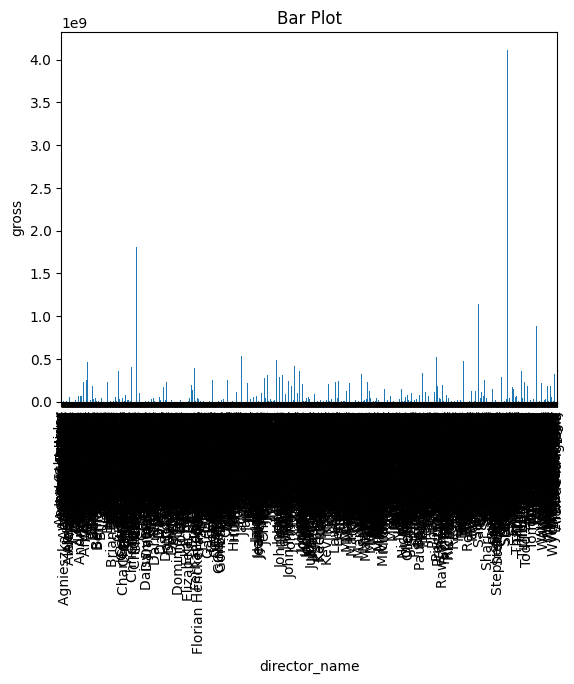


====== Data Analysis & Visualization ======
1. Load Dataset
2. Explore Data
3. DataFrame Operations
4. Handle Missing Data
5. Statistics
6. Visualization
7. Save Visualization
8. Exit


Enter your choice:  7
Enter file name (e.g. plot.png):  bar_chart.png


Visualization saved as bar_chart.png successfully

====== Data Analysis & Visualization ======
1. Load Dataset
2. Explore Data
3. DataFrame Operations
4. Handle Missing Data
5. Statistics
6. Visualization
7. Save Visualization
8. Exit


Enter your choice:  8


Exiting the program. Goodbye!


<Figure size 640x480 with 0 Axes>

In [4]:
app = SalesAnalyzer()

while True:
    print("\n====== Data Analysis & Visualization ======")
    print("1. Load Dataset")
    print("2. Explore Data")
    print("3. DataFrame Operations")
    print("4. Handle Missing Data")
    print("5. Statistics")
    print("6. Visualization")
    print("7. Save Visualization")
    print("8. Exit")
    print("==========================================")

    ch = int(input("Enter your choice: "))

    match ch:
        case 1:
            print("\n== Load Dataset ==")
            path = input("Enter CSV file path: ")
            app.load_data(path)

        case 2:
            app.explore()

        case 3:
            app.operations()

        case 4:
            app.clean()

        case 5:
            app.stats()

        case 6:
            app.visualize()

        case 7:
            app.save_plot()

        case 8:
            print("Exiting the program. Goodbye!")
            break

        case _:
            print("Invalid choice!")